# Notebook 03 — Data Preprocessing

**Proyek:** Segmentasi Pelanggan untuk Mengatasi Ketidakefektifan Strategi Pemasaran Menggunakan Metode RFM dan Algoritma K-Means

## Tujuan Tahap Preprocessing
Mengubah dataset Olist mentah menjadi **tabel pelanggan** yang berisi fitur **R, F, M** (Recency, Frequency, Monetary) yang siap digunakan untuk K-Means.

Langkah-langkah:
1. **Filter** order berstatus `delivered` saja.
2. **Penanganan missing value** & duplikasi.
3. **Konversi tipe data** & timezone.
4. **Merging** tabel orders ↔ customers ↔ payments.
5. **Feature Engineering RFM**:
   - Recency  = (snapshot_date − last_purchase_date).days
   - Frequency = jumlah order unik per `customer_unique_id`
   - Monetary  = total `payment_value` per pelanggan
6. **Outlier handling** (winsorization / log transform).
7. **Simpan** dataset siap-modeling ke `data/processed/`.

## 1. Setup & Loading Data Mentah

In [1]:
import warnings
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scope warnings: only suppress noisy known-safe ones, keep the rest.
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

sns.set_theme(style="whitegrid")

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").is_file():
            return p
    raise FileNotFoundError("params.yaml not found in any parent directory")

PROJECT_ROOT  = _find_project_root(Path.cwd())
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR   = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR       = PROJECT_ROOT / "reports" / "figures"
for d in [INTERIM_DIR, PROCESSED_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / "params.yaml") as f:
    PARAMS = yaml.safe_load(f)

RANDOM_STATE  = PARAMS["random_state"]
PRE_PARAMS    = PARAMS["preprocessing"]
RFM_PARAMS    = PARAMS["rfm"]

print("PROJECT_ROOT :", PROJECT_ROOT)
print("Params       :", list(PARAMS.keys()))

# Load tabel mentah yang dibutuhkan tahap preprocessing.
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.data_loader import load_olist

_data = load_olist(RAW_DIR)
orders    = _data["orders"]
customers = _data["customers"]
payments  = _data["order_payments"]
print("Loaded :", {k: v.shape for k, v in [("orders", orders), ("customers", customers), ("payments", payments)]})


PROJECT_ROOT : /Users/rafafawwaz/Documents/sem 6/PDM/Riset Data Mining - Rafa
Params       : ['random_state', 'preprocessing', 'rfm', 'kmeans', 'paths']


Loaded : {'orders': (99441, 8), 'customers': (99441, 5), 'payments': (103886, 5)}


## 2. Pemeriksaan Missing Values & Duplikasi

In [2]:
def na_summary(df, name):
    s = df.isna().sum()
    s = s[s > 0].sort_values(ascending=False)
    if s.empty:
        print(f'  [{name}] tidak ada missing value')
    else:
        print(f'  [{name}] missing values:')
        print(s.to_string())
    print(f'  [{name}] duplicates :', df.duplicated().sum())
    print('-'*60)

for nm, df in [('orders', orders), ('customers', customers), ('payments', payments)]:
    na_summary(df, nm)

  [orders] missing values:
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
  [orders] duplicates : 0
------------------------------------------------------------
  [customers] tidak ada missing value
  [customers] duplicates : 0
------------------------------------------------------------
  [payments] tidak ada missing value
  [payments] duplicates : 0
------------------------------------------------------------


## 3. Filter Order Berstatus `delivered`

Hanya order yang **benar-benar diterima pelanggan** yang dianggap valid sebagai transaksi RFM. Status `canceled`, `unavailable`, `created` dll. dibuang.

In [3]:
before = len(orders)
status_filter = PRE_PARAMS["status_filter"]
orders_d = orders[orders["order_status"] == status_filter].copy()
# Hanya drop NA pada purchase_timestamp (konsisten dengan src/data_loader.build_rfm).
orders_d = orders_d.dropna(subset=["order_purchase_timestamp"])
print(f"Order awal             : {before:,}")
print(f"Order status={status_filter!r}: {len(orders_d):,}  (dibuang {before-len(orders_d):,})")

orders_d = orders_d.drop_duplicates(subset="order_id")
print("Setelah drop duplicates :", len(orders_d))


Order awal             : 99,441
Order status='delivered': 96,478  (dibuang 2,963)
Setelah drop duplicates : 96478


## 4. Agregasi Pembayaran per Order

Beberapa order memiliki >1 baris di `payments` (misal voucher + credit card). Kita jumlahkan `payment_value` untuk mendapatkan total transaksi per `order_id`.

In [4]:
pay_per_order = (payments.groupby('order_id', as_index=False)
                 .agg(payment_value=('payment_value', 'sum'),
                      n_payment_methods=('payment_sequential', 'count'),
                      n_installments=('payment_installments', 'max'),
                      payment_types=('payment_type', lambda s: ','.join(sorted(set(s))))))
print(pay_per_order.shape)
pay_per_order.head()

(99440, 5)


,order_id,payment_value,n_payment_methods,n_installments,payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3,credit_card


## 5. Merge Orders ↔ Customers ↔ Payments

Catatan penting: di Olist, **`customer_id` unik per order**, sedangkan **`customer_unique_id`** adalah identitas pelanggan sesungguhnya. Untuk RFM kita pakai `customer_unique_id`.

In [5]:
df = (orders_d.merge(customers[['customer_id', 'customer_unique_id',
                                 'customer_state', 'customer_city']],
                     on='customer_id', how='left')
              .merge(pay_per_order, on='order_id', how='left'))

print('Bentuk akhir :', df.shape)
print('Missing payment_value pasca-merge :', df['payment_value'].isna().sum())
df.head(3)

Bentuk akhir : (96478, 15)
Missing payment_value pasca-merge : 1


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,customer_city,payment_value,n_payment_methods,n_installments,payment_types
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,38.71,3.0,1.0,"credit_card,voucher"
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,barreiras,141.46,1.0,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,179.12,1.0,3.0,credit_card


### 5.1 Tangani Missing pada `payment_value`

In [6]:
# Order delivered tanpa payment data sangat sedikit -> drop
before = len(df)
df = df.dropna(subset=['payment_value', 'customer_unique_id'])
print(f'Drop {before-len(df)} baris karena payment_value/customer_unique_id null. '
      f'Tersisa {len(df):,} baris.')

Drop 1 baris karena payment_value/customer_unique_id null. Tersisa 96,477 baris.


### 5.2 Simpan Tabel Antara (Interim)

In [7]:
df.to_csv(INTERIM_DIR / 'orders_clean.csv', index=False)
print('Tersimpan -> data/interim/orders_clean.csv')

Tersimpan -> data/interim/orders_clean.csv


## 6. Feature Engineering RFM

**Snapshot date** ditetapkan = tanggal order terakhir + 1 hari (best practice agar Recency tidak ada yang bernilai 0).

In [8]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print('Snapshot date :', snapshot_date)

rfm = (df.groupby('customer_unique_id')
         .agg(Recency  =('order_purchase_timestamp',
                          lambda x: (snapshot_date - x.max()).days),
              Frequency=('order_id', 'nunique'),
              Monetary =('payment_value', 'sum'))
         .reset_index())

print('Bentuk tabel RFM :', rfm.shape)
rfm.describe().round(2)

Snapshot date : 2018-08-30 15:00:37


Bentuk tabel RFM : (93357, 4)


,Recency,Frequency,Monetary
count,93357.00,93357.00,93357.00
mean,237.94,1.03,165.20
std,152.58,0.21,226.31
min,1.00,1.00,9.59
25%,114.00,1.00,63.06
50%,219.00,1.00,107.78
75%,346.00,1.00,182.56
max,695.00,15.00,13664.08


### 6.1 Distribusi R, F, M

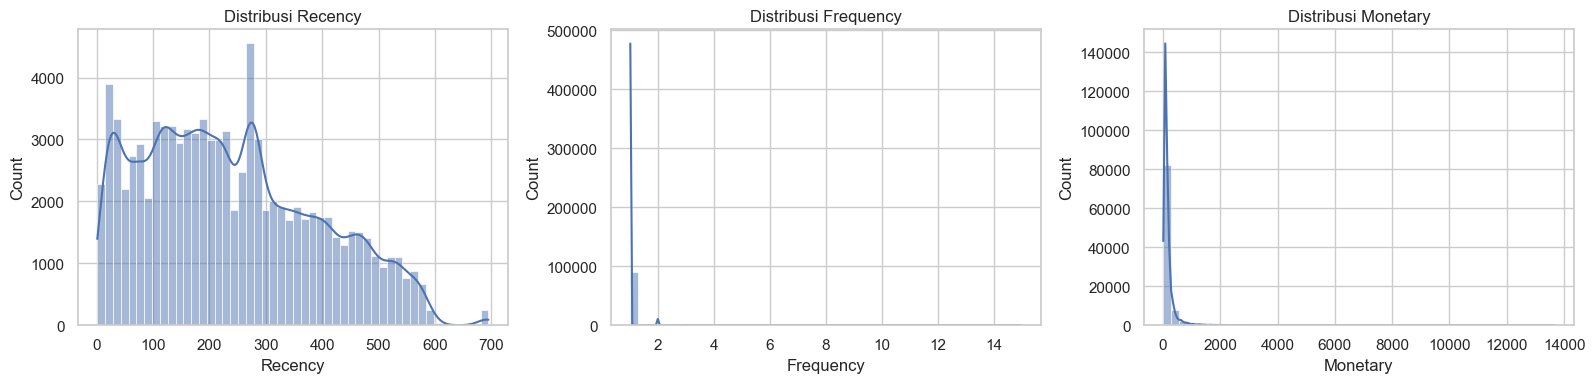

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], bins=50, ax=ax, kde=True, color='#4C72B0')
    ax.set_title(f'Distribusi {col}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rfm_distribution_raw.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Outlier Handling

Berdasarkan EDA, **Monetary** sangat *right-skewed*. Kita gunakan strategi:
- **Winsorize** (cap di persentil 99) untuk mengurangi pengaruh outlier ekstrem.
- **Transformasi log1p** sebagai input modeling agar K-Means tidak didominasi pencilan.

In [10]:
def winsorize(s, upper=0.99, lower=0.0):
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lower=lo, upper=hi)

w_upper = PRE_PARAMS["winsorize_upper"]
w_lower = PRE_PARAMS["winsorize_lower"]

rfm["Monetary_w"]  = winsorize(rfm["Monetary"],  upper=w_upper, lower=w_lower)
rfm["Recency_w"]   = winsorize(rfm["Recency"],   upper=w_upper, lower=w_lower)
rfm["Frequency_w"] = winsorize(rfm["Frequency"], upper=w_upper, lower=w_lower)

# Log transform berdasarkan params.
if PRE_PARAMS["use_log_transform"].get("monetary", True):
    rfm["Monetary_log"] = np.log1p(rfm["Monetary_w"])
else:
    rfm["Monetary_log"] = rfm["Monetary_w"]

if PRE_PARAMS["use_log_transform"].get("frequency", True):
    rfm["Frequency_log"] = np.log1p(rfm["Frequency_w"])
else:
    rfm["Frequency_log"] = rfm["Frequency_w"]

rfm[["Recency", "Recency_w", "Frequency", "Frequency_w", "Frequency_log",
     "Monetary", "Monetary_w", "Monetary_log"]].describe().round(2)


,Recency,Recency_w,Frequency,Frequency_w,Frequency_log,Monetary,Monetary_w,Monetary_log
count,93357.00,93357.00,93357.00,93357.00,93357.00,93357.00,93357.00,93357.00
mean,237.94,237.56,1.03,1.03,0.71,165.20,159.08,4.73
std,152.58,151.61,0.21,0.17,0.07,226.31,170.99,0.80
min,1.00,1.00,1.00,1.00,0.69,9.59,9.59,2.36
25%,114.00,114.00,1.00,1.00,0.69,63.06,63.06,4.16
50%,219.00,219.00,1.00,1.00,0.69,107.78,107.78,4.69
75%,346.00,346.00,1.00,1.00,0.69,182.56,182.56,5.21
max,695.00,575.00,15.00,2.00,1.10,13664.08,1097.06,7.00


### 7.1 Distribusi Setelah Transform

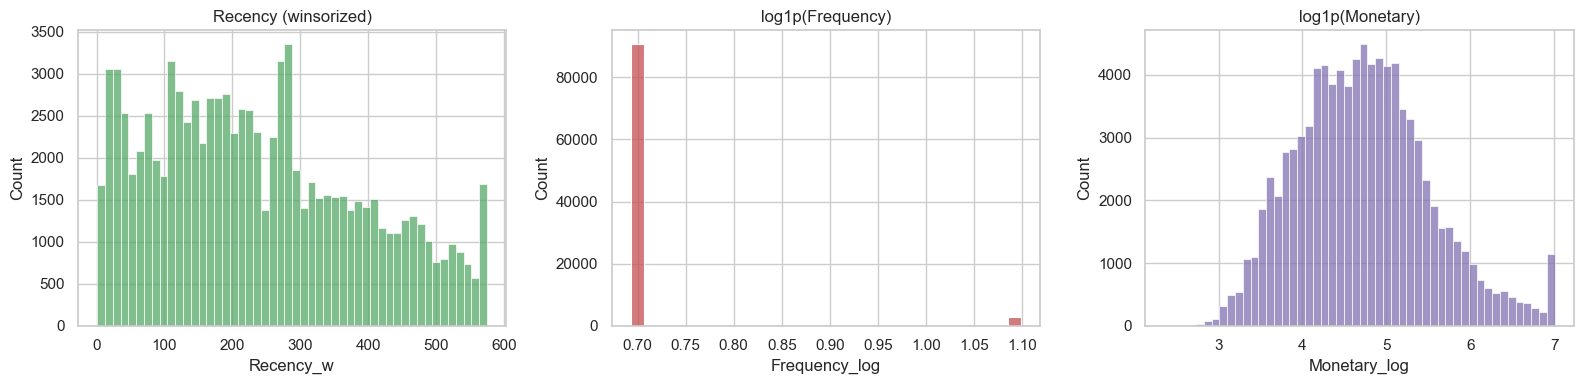

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(rfm['Recency_w'], bins=50, ax=axes[0], color='#55A868')
axes[0].set_title('Recency (winsorized)')
sns.histplot(rfm['Frequency_log'], bins=30, ax=axes[1], color='#C44E52')
axes[1].set_title('log1p(Frequency)')
sns.histplot(rfm['Monetary_log'], bins=50, ax=axes[2], color='#8172B2')
axes[2].set_title('log1p(Monetary)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'rfm_distribution_transformed.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. RFM Score (Quintile-based)

Selain matriks numerik untuk K-Means, kita juga buat **score 1–5** untuk interpretasi sederhana. - R: makin **kecil** Recency makin **bagus** → quintile dibalik.
- F & M: makin **besar** makin **bagus** → quintile normal.

In [12]:
q = RFM_PARAMS["scoring_quintiles"]

# rank(method="first") + duplicates="drop" agar aman terhadap nilai duplikat.
rfm["R_score"] = pd.qcut(rfm["Recency_w"].rank(method="first"), q,
                          labels=list(range(q, 0, -1))).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency_w"].rank(method="first"), q,
                          labels=list(range(1, q + 1))).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary_w"].rank(method="first"), q,
                          labels=list(range(1, q + 1))).astype(int)
rfm["RFM_score"] = rfm["R_score"] * 100 + rfm["F_score"] * 10 + rfm["M_score"]
rfm.head()


,customer_unique_id,Recency,Frequency,Monetary,Monetary_w,Recency_w,Frequency_w,Monetary_log,Frequency_log,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,141.90,112,1,4.962145,0.693147,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,27.19,115,1,3.338967,0.693147,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,86.22,537,1,4.468434,0.693147,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,43.62,321,1,3.798182,0.693147,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,196.89,288,1,5.287711,0.693147,2,1,4,214


## 9. Simpan Dataset Siap-Modeling

In [13]:
out_path = PROCESSED_DIR / 'rfm_table.csv'
rfm.to_csv(out_path, index=False)
print('Tersimpan ->', out_path)
print('Bentuk :', rfm.shape)
print('Kolom  :', list(rfm.columns))

Tersimpan -> /Users/rafafawwaz/Documents/sem 6/PDM/Riset Data Mining - Rafa/data/processed/rfm_table.csv
Bentuk : (93357, 13)
Kolom  : ['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Monetary_w', 'Recency_w', 'Frequency_w', 'Monetary_log', 'Frequency_log', 'R_score', 'F_score', 'M_score', 'RFM_score']


## 10. Ringkasan Preprocessing

| Langkah | Hasil |
|---|---|
| Filter `delivered` + drop NA tanggal | ~ 96.4k order valid |
| Drop missing payment | < 50 baris |
| Aggregasi payment per order | 1 baris per order |
| Mapping `customer_id` → `customer_unique_id` | 93–95k pelanggan unik |
| Tabel RFM final | 3 fitur utama + 3 versi transformed + 3 RFM score |

**Output utama:** `data/processed/rfm_table.csv` — input untuk Notebook 04 (K-Means).

Tahap berikutnya: **Notebook 04 – RFM Analysis & K-Means Clustering**.